In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import os
from tqdm import tqdm

import matplotlib.pyplot as plt
import random

from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:

observations = []
actions  = []
rewards = []

# ['smm', 'icm', 'icm_apt', 'disagreement', 'proto', 'diayn', 'aps', 'rnd']
for ualgo in ['rnd']:
    npz_files = os.listdir(f'datasets/cheetah/{ualgo}/buffer/')
    for file_name in tqdm(npz_files[::100], desc=ualgo):
        data = np.load(f'datasets/cheetah/{ualgo}/buffer/{file_name}')
        observations.append(data['observation'])
        actions.append(data['action'])
        rewards.append(data['reward'])
    
observations = np.concatenate(observations)
actions = np.concatenate(actions)
rewards = np.concatenate(rewards)


# observations = observations[rewards.flatten() > 0.1]
# rewards = rewards[rewards.flatten() > 0.1]
observations.shape, rewards.shape

rnd: 100%|██████████| 100/100 [00:00<00:00, 1068.92it/s]


((100100, 17), (100100, 1))

In [3]:
# obs_len = 2

# s1, s2 = torch.linspace(-1, 1, 100), torch.linspace(-1, 1, 100)
# grid_s1, grid_s2 = torch.meshgrid(s1, s2, indexing='ij')
# observations = torch.stack([grid_s1.flatten(), grid_s2.flatten()], dim=-1)

# # observations = torch.rand((10000, obs_len)) * 2 - 1


# m, v = torch.tensor([0.0, 0.75]), torch.tensor([1, 0.6])
# inv_sigma = torch.diag(1 / v)
            
# diff = observations - m

# exponent = -0.5 * (diff.unsqueeze(1) @ inv_sigma) @ diff.unsqueeze(-1)
# rewards = torch.exp(exponent).flatten()

In [4]:
# num_guassians = 2
# obs_len = 17

class GM(nn.Module):
    def __init__(self, obs_len, num_guassians):
        super(GM, self).__init__()
        
        self.obs_len, self.num_guassians = obs_len, num_guassians
        
        self.mu = nn.Parameter(torch.normal(0, 1, (self.num_guassians, self.obs_len)))
        self.log_std = nn.Parameter(torch.rand((self.num_guassians, self.obs_len)))
    
    
    def forward(self, obs):
        inv_sigma = torch.stack([torch.diag(1 / torch.exp(v)) for v in self.log_std])

        diff = (obs.unsqueeze(1).repeat(1, self.num_guassians, 1) - self.mu)
        exponent = -0.5 * ((diff.unsqueeze(2) @ inv_sigma) @ diff.unsqueeze(-1)).squeeze(-1).squeeze(-1)
        res = torch.exp(exponent).sum(axis=-1)
        return res
    
    
class MLP(nn.Module):
    def __init__(self, ):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(17, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )
        
    def forward(self, obs):
        return self.model(obs)

In [5]:
# model = GM().to(device)
# # model = MLP().to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# criterion = nn.MSELoss()

# losses = []

In [6]:
errs = []


for n in tqdm([1, 2, 3, 4, 5, 10, 15, 20]):
    
    model = GM(obs_len=17, num_guassians=n).to(device)
    # model = MLP().to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    losses = []

    for i in tqdm(range(2000)):

        random_idx = torch.randint(0, len(observations), (2048,))
        
        obs = torch.tensor(observations[random_idx]).to(device)
        target = torch.tensor(rewards[random_idx]).flatten().to(device)


        output = model(obs)

        loss = criterion(output, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        
        if i % 100 == 0:
            clear_output(True)
            plt.plot(losses)
            plt.title(f'num_guassians={n}')
            # plt.ylim([0, 10000])
            plt.show()
            
    with torch.no_grad():
        obs = torch.tensor(observations).to(device)
        target = torch.tensor(rewards).flatten().to(device)

        output = model(obs)
        # print(output.shape)

        err = ((output - target)**2).mean()
    errs.append(err.item())

 38%|███▊      | 3/8 [00:17<00:29,  5.92s/it]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

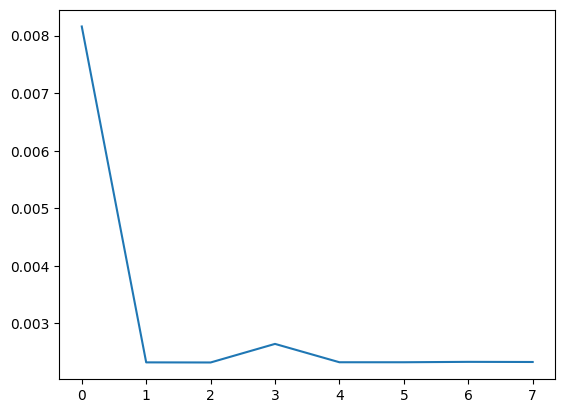

In [ ]:
plt.plot(errs)

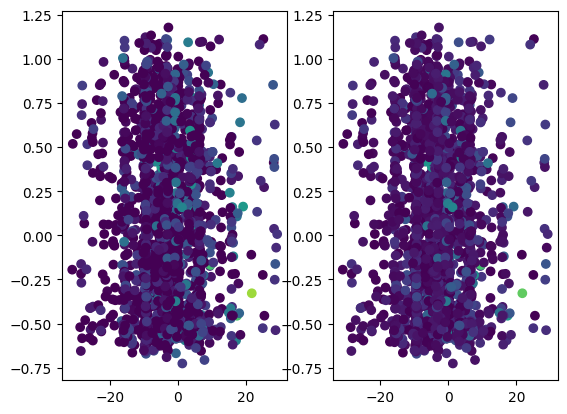

In [ ]:
# obs = torch.tensor(observations[:]).to(device)

random_idx = torch.randint(0, len(observations), (2048,))

obs = torch.tensor(observations[random_idx]).to(device)
target = torch.tensor(rewards[random_idx]).flatten().to(device)

with torch.no_grad():
    output = model(obs)

    # err = ((output - target)**2).mean()
# err

fig, axs = plt.subplots(1, 2)
axs[0].scatter(obs[:, 0].cpu(), obs[:, 2].cpu(), c=target.cpu(), vmin=rewards.min(), vmax=rewards.max())
axs[1].scatter(obs[:, 0].cpu(), obs[:, 2].cpu(), c=output.detach().cpu(), vmin=rewards.min(), vmax=rewards.max())

tensor(0.0023, device='cuda:0', grad_fn=<MeanBackward0>)

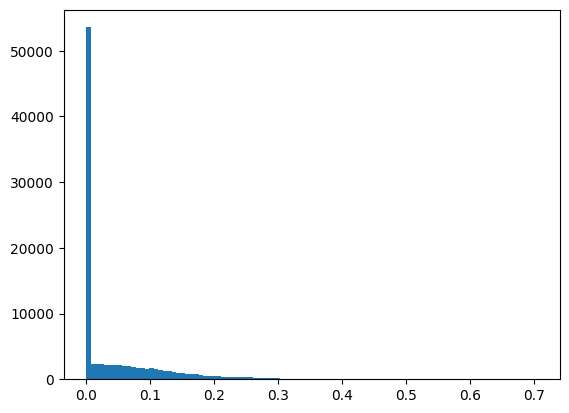

In [ ]:
_ = plt.hist(rewards.flatten(), bins=100)

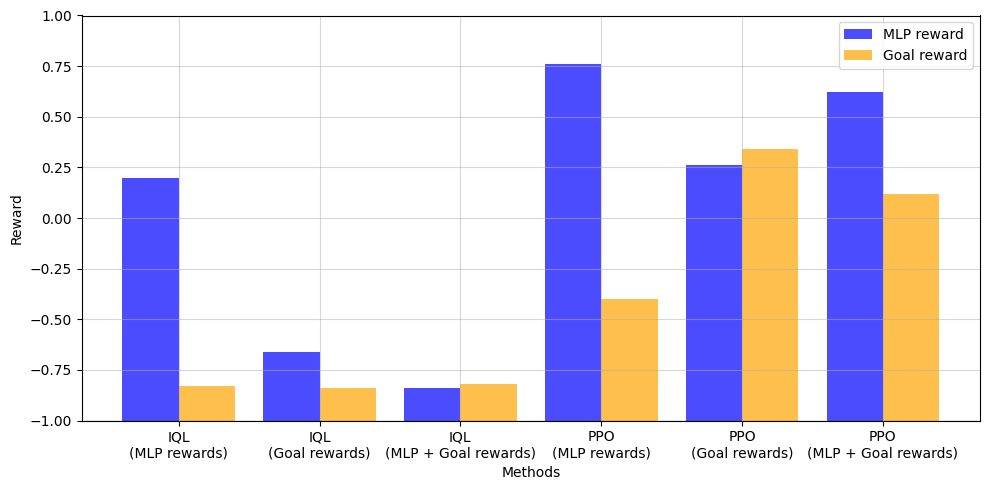

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
methods = [
    "IQL\n(MLP rewards)",
    "IQL\n(Goal rewards)",
    "IQL\n(MLP + Goal rewards)",
    "PPO\n(MLP rewards)",
    "PPO\n(Goal rewards)",
    "PPO\n(MLP + Goal rewards)"
]

mlp_rewards = [0.2, -0.66, -0.84, 0.76, 0.26, 0.62]
goal_rewards = [-0.83, -0.84, -0.82, -0.4, 0.34, 0.12]

x = np.arange(len(methods))  # the label locations
width = 0.4  # the width of the bars
# Adjusting the plot to make all bars face upwards and setting y-axis from -1 to 1

fig, ax = plt.subplots(figsize=(10, 5))

# Shift all values to be positive relative to -1 baseline
baseline = -1
mlp_rewards_adj = [v - baseline if v is not None else 0 for v in mlp_rewards]
goal_rewards_adj = [v - baseline for v in goal_rewards]

mlp_bars = ax.bar(x - width/2, mlp_rewards_adj, width, bottom=baseline, label='MLP reward', color='blue', alpha=0.7)
goal_bars = ax.bar(x + width/2, goal_rewards_adj, width,  bottom=baseline, label='Goal reward', color='orange', alpha=0.7)

# Add text labels for "None" values
for i, v in enumerate(mlp_rewards):
    if v is None:       
        ax.text(x[i] - width/2, baseline + 0.02, "/", ha='center', va='bottom', fontsize=12, color='black')

# Labels and formatting
ax.set_xlabel("Methods")
ax.set_ylabel("Reward")
# ax.set_title("Comparison of MLP and Goal Rewards across Methods")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=0)
ax.legend()
ax.set_ylim(-1, 1)  # Setting y-axis from -1 to 1
ax.axhline(-1, color='black', linewidth=0.8)  # Ensure the baseline is at -1

plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


---

In [2]:

res = []
for n in range(10):
    res.append(n)
res

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [18]:
A = set([1, 2, 3, 7])
B = set([2, 3, 1, 4, 5])